# Experimento 7.6 — Investimento: Maior Subsequência Crescente (LIS)
**Disciplina:** Análise de Algoritmos
**Tema:** 7.6 — Investimento

**Integrante:** Yan Pedro Façanha Brasileiro

---

## Contexto
Um analista financeiro deseja identificar períodos de crescimento sustentado no valor de uma ação ao longo do tempo. Dada uma série temporal contendo o preço diário do ativo, o objetivo é encontrar a maior sequência de dias em que os preços apresentaram tendência crescente, sem exigir que esses dias sejam consecutivos.

## Problema
Dado um vetor preenchido com os preços históricos de uma ação, determinar o **tamanho da maior subsequência estritamente crescente (LIS — *Longest Increasing Subsequence*) e recuperar os seus respectivos elementos** (os preços que compõem a tendência).

## Algoritmos Comparados
Para analisar experimentalmente o impacto do tamanho da entrada sobre o tempo médio de execução, implementamos e comparamos três abordagens:

1. **Algoritmo Ingênuo (Força Bruta):** Explora e testa exaustivamente todas as subsequências possíveis para encontrar a maior. Complexidade: $O(2^n)$.
2. **Programação Dinâmica Recursiva com Memoização:** Abordagem *Top-Down* que divide o problema recursivamente e armazena os estados em cache para evitar recomputações redundantes. Complexidade: $O(n^2)$.
3. **Programação Dinâmica Iterativa:** Abordagem *Bottom-Up* que preenche uma tabela de decisões sequencialmente e reconstrói o caminho ótimo. Complexidade: $O(n^2)$.

## Implementação dos Algoritmos

In [6]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np

def lis_iterativo(precos):
    n = len(precos)
    if n == 0: return 0, []
    dp = [1] * n
    parent = [-1] * n
    for i in range(1, n):
        for j in range(i):
            if precos[i] > precos[j] and dp[j] + 1 > dp[i]:
                dp[i] = dp[j] + 1
                parent[i] = j
    max_idx = int(np.argmax(dp))
    max_len = dp[max_idx]
    solucao = []
    curr = max_idx
    while curr != -1:
        solucao.append(precos[curr])
        curr = parent[curr]
    solucao.reverse()
    return max_len, solucao

def lis_recursivo_memo(precos):
    n = len(precos)
    if n == 0: return 0, []
    memo = {}
    decisoes = {}
    def lcs_td(idx, prev_idx):
        if idx == n: return 0
        state = (idx, prev_idx)
        if state in memo: return memo[state]
        ans_exclude = lcs_td(idx + 1, prev_idx)
        ans_include = 0
        if prev_idx == -1 or precos[idx] > precos[prev_idx]:
            ans_include = 1 + lcs_td(idx + 1, idx)
        if ans_include > ans_exclude:
            memo[state] = ans_include
            decisoes[state] = True
        else:
            memo[state] = ans_exclude
            decisoes[state] = False
        return memo[state]
    max_len = lcs_td(0, -1)
    solucao = []
    curr_idx, curr_prev = 0, -1
    while curr_idx < n:
        state = (curr_idx, curr_prev)
        if decisoes.get(state, False):
            solucao.append(precos[curr_idx])
            curr_prev = curr_idx
        curr_idx += 1
    return max_len, solucao

def lis_ingenuo(precos):
    n = len(precos)
    def helper(idx, prev_idx):
        if idx == n: return 0, []
        len_ex, seq_ex = helper(idx + 1, prev_idx)
        len_inc, seq_inc = 0, []
        if prev_idx == -1 or precos[idx] > precos[prev_idx]:
            l, s = helper(idx + 1, idx)
            len_inc = 1 + l
            seq_inc = [precos[idx]] + s
        if len_inc > len_ex: return len_inc, seq_inc
        return len_ex, seq_ex
    return helper(0, -1)

## Coleta dos Tempos

In [7]:
import sys
import time
import random

# Aumenta o limite máximo de recursão do Python
sys.setrecursionlimit(5000)

def gerador_entradas(tamanho):
    return [random.randint(10, 500) for _ in range(tamanho)]

# Usamos apenas 3 tamanhos para conseguir desenhar a linha no gráfico
tamanhos_pequenos = [10, 15, 20]
tamanhos_grandes = [100, 500, 1000]

tempos_pequenos = {'ingenuo': [], 'recursivo': [], 'iterativo': []}
tempos_grandes = {'recursivo': [], 'iterativo': []}

print("===============================================================")
print("--- ETAPA 1: ENTRADAS PEQUENAS (COMPARAÇÃO TOTAL) ---")
print("===============================================================\n")

# Variável para garantir que o exemplo seja impresso APENAS UMA VEZ
exibiu_exemplo_pequeno = False

for n in tamanhos_pequenos:
    t_ing, t_rec, t_ite = 0, 0, 0

    for i in range(10):
        entrada = gerador_entradas(n)

        # Coleta os resultados
        l_ite, seq_ite = lis_iterativo(entrada)
        l_rec, seq_rec = lis_recursivo_memo(entrada)
        l_ing, seq_ing = lis_ingenuo(entrada)

        # Verificação rigorosa de corretude
        assert l_ite == l_rec == l_ing, f"Erro de corretude em n={n}!"

        # Print demonstrativo APENAS NA PRIMEIRA VEZ GERAL
        if not exibiu_exemplo_pequeno:
            print(f"🔹 [EXEMPLO ÚNICO - TAMANHO N = {n}]")
            print(f"  » Preços (Entrada):        {entrada}")
            print(f"  » Saída Força Bruta:       Tamanho = {l_ing}, Sequência = {seq_ing}")
            print(f"  » Saída PD Recursiva Memo: Tamanho = {l_rec}, Sequência = {seq_rec}")
            print(f"  » Saída PD Iterativa:      Tamanho = {l_ite}, Sequência = {seq_ite}")
            print("-" * 65)
            exibiu_exemplo_pequeno = True

        # Medição de tempos
        t0 = time.perf_counter(); lis_ingenuo(entrada); t_ing += (time.perf_counter() - t0)
        t0 = time.perf_counter(); lis_recursivo_memo(entrada); t_rec += (time.perf_counter() - t0)
        t0 = time.perf_counter(); lis_iterativo(entrada); t_ite += (time.perf_counter() - t0)

    tempos_pequenos['ingenuo'].append(t_ing / 10)
    tempos_pequenos['recursivo'].append(t_rec / 10)
    tempos_pequenos['iterativo'].append(t_ite / 10)
    print(f"Medições para n={n} concluídas.")

print("\n===============================================================")
print("--- ETAPA 2: ENTRADAS MÉDIAS E GRANDES (APENAS P. DINÂMICA) --")
print("===============================================================\n")

# Variável para garantir que o exemplo seja impresso APENAS UMA VEZ
exibiu_exemplo_grande = False

for n in tamanhos_grandes:
    t_rec, t_ite = 0, 0

    for i in range(10):
        entrada = gerador_entradas(n)

        # Coleta resultados
        l_ite, seq_ite = lis_iterativo(entrada)
        l_rec, seq_rec = lis_recursivo_memo(entrada)

        assert l_ite == l_rec, f"Erro de corretude em n={n}!"

        # Print demonstrativo APENAS NA PRIMEIRA VEZ GERAL
        if not exibiu_exemplo_grande:
            print(f"🔸 [EXEMPLO ÚNICO - TAMANHO N = {n}]")
            print(f"  » Preços (Primeiros 15 dados de entrada): {entrada[:15]}")
            print(f"  » Saída PD Recursiva Memo (Tamanho {l_rec}): Sequência = {seq_rec}")
            print(f"  » Saída PD Iterativa      (Tamanho {l_ite}): Sequência = {seq_ite}")
            print("-" * 65)
            exibiu_exemplo_grande = True

        # Medição de tempos
        t0 = time.perf_counter(); lis_recursivo_memo(entrada); t_rec += (time.perf_counter() - t0)
        t0 = time.perf_counter(); lis_iterativo(entrada); t_ite += (time.perf_counter() - t0)

    tempos_grandes['recursivo'].append(t_rec / 10)
    tempos_grandes['iterativo'].append(t_ite / 10)
    print(f"Medições para n={n} concluídas.\n")

--- ETAPA 1: ENTRADAS PEQUENAS (COMPARAÇÃO TOTAL) ---

🔹 [EXEMPLO ÚNICO - TAMANHO N = 10]
  » Preços (Entrada):        [488, 228, 459, 348, 233, 368, 44, 437, 456, 355]
  » Saída Força Bruta:       Tamanho = 5, Sequência = [228, 233, 368, 437, 456]
  » Saída PD Recursiva Memo: Tamanho = 5, Sequência = [228, 233, 368, 437, 456]
  » Saída PD Iterativa:      Tamanho = 5, Sequência = [228, 348, 368, 437, 456]
-----------------------------------------------------------------
Medições para n=10 concluídas.
Medições para n=15 concluídas.
Medições para n=20 concluídas.

--- ETAPA 2: ENTRADAS MÉDIAS E GRANDES (APENAS P. DINÂMICA) --

🔸 [EXEMPLO ÚNICO - TAMANHO N = 100]
  » Preços (Primeiros 15 dados de entrada): [84, 226, 173, 361, 330, 476, 278, 53, 440, 115, 223, 181, 316, 232, 90]
  » Saída PD Recursiva Memo (Tamanho 16): Sequência = [53, 86, 103, 148, 178, 241, 251, 259, 261, 292, 318, 324, 327, 328, 356, 434]
  » Saída PD Iterativa      (Tamanho 16): Sequência = [84, 173, 181, 185, 229, 24

## Geração dos Gráficos


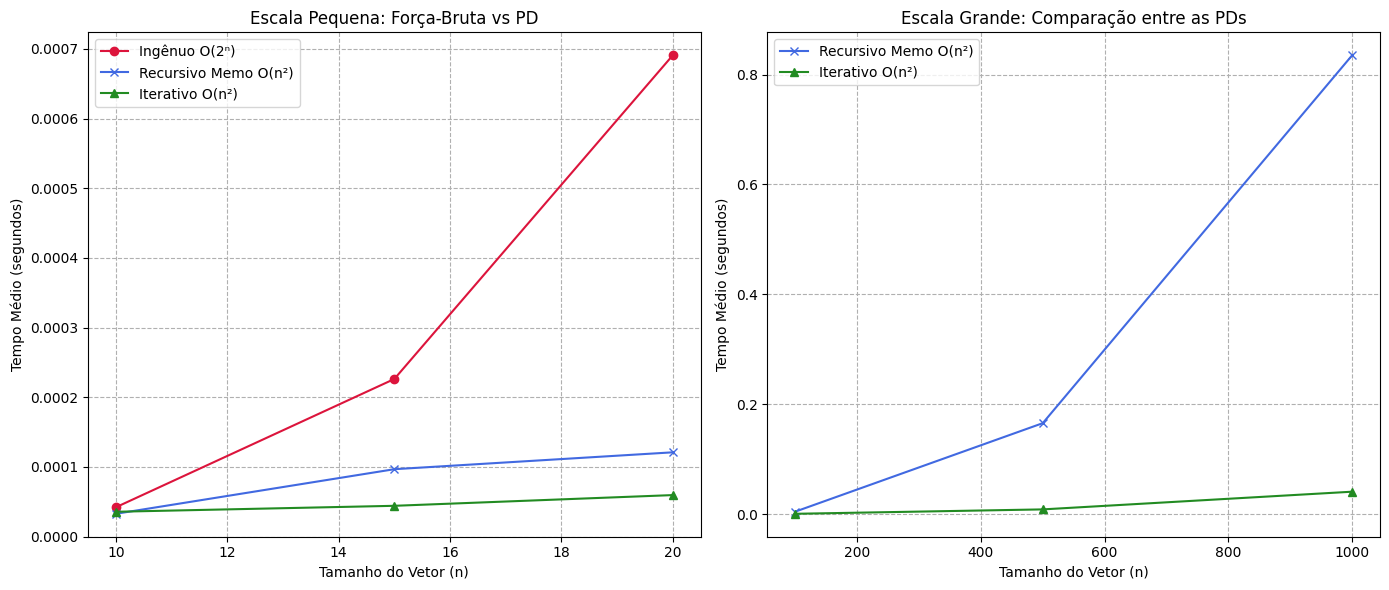

In [8]:
plt.figure(figsize=(14, 6))

# Gráfico 1: Escala Pequena (Exponencial vs Programação Dinâmica)
plt.subplot(1, 2, 1)
plt.plot(tamanhos_pequenos, tempos_pequenos['ingenuo'], label='Ingênuo O(2ⁿ)', color='crimson', marker='o')
plt.plot(tamanhos_pequenos, tempos_pequenos['recursivo'], label='Recursivo Memo O(n²)', color='royalblue', marker='x')
plt.plot(tamanhos_pequenos, tempos_pequenos['iterativo'], label='Iterativo O(n²)', color='forestgreen', marker='^')
plt.title('Escala Pequena: Força-Bruta vs PD')
plt.xlabel('Tamanho do Vetor (n)')
plt.ylabel('Tempo Médio (segundos)')
plt.legend()
plt.grid(True, linestyle='--')

# Gráfico 2: Escala Grande (Apenas as duas abordagens eficientes)
plt.subplot(1, 2, 2)
plt.plot(tamanhos_grandes, tempos_grandes['recursivo'], label='Recursivo Memo O(n²)', color='royalblue', marker='x')
plt.plot(tamanhos_grandes, tempos_grandes['iterativo'], label='Iterativo O(n²)', color='forestgreen', marker='^')
plt.title('Escala Grande: Comparação entre as PDs')
plt.xlabel('Tamanho do Vetor (n)')
plt.ylabel('Tempo Médio (segundos)')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()